In [121]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import random
import seaborn as sns
sns.set_theme()

In [122]:
data = loadmat('cluster_dataset.mat')

In [123]:
X = data['data']
x1 = np.array([i[0] for i in X])
x2 = np.array([i[1] for i in X])

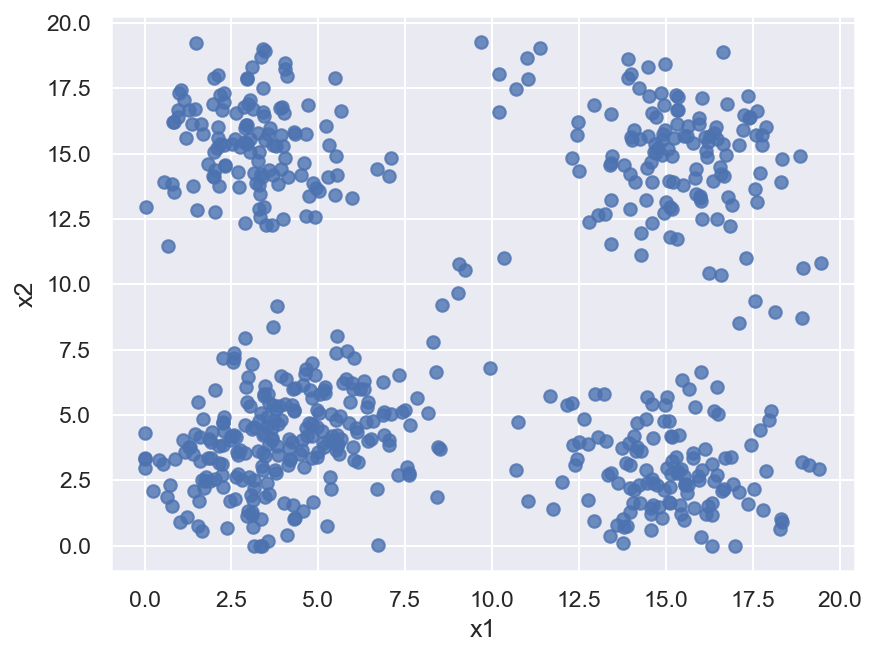

In [124]:
plt.figure(dpi=150)
plt.scatter(x1,x2,color='b',alpha=0.8)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [125]:
#预设聚类簇数k：请观察数据集散点图，预计聚类簇数k
k = 4

In [126]:
#随机选择数据集中k个点作为初始聚类中心
def init_centers(X,k):
    """
    输入：X:数据集(ndarray), k：预设的聚类簇数(int)
    输出：centers：初始化的中心集（建议：元素为ndarray的list)
    可能使用的函数：random.randint
    注意：需保证随机取的样本不重复
    """
    n=X.shape[0]
    selected_indices=set()
    while len(selected_indices)<k:
        idx=random.randint(0,n-1)
        selected_indices.add(idx)
    centers=[X[idx] for idx in selected_indices]
    return centers

In [127]:
#向量欧氏距离计算，用于计算每个样本和中心的距离，可用于簇分配和代价函数计算
def distance(v1, v2):
    """
    输入：v1:样本(ndarray), v2:当前对应的中心(ndarray)
    输出：distance:欧氏距离(float/ndarray)
    """
    distance=np.linalg.norm(v1-v2)
    return distance

In [128]:
#将样本分配到距离最近的中心所在的簇
def cluster_assignment(X, centers):
    """
    输入：X:数据集(ndarray), centers：当前中心集（建议：元素为ndarray的list)
    输出：assignment(建议：字典：key为簇标号、value为元素是ndarray的list)
    可能使用的函数：np.argmin
    注意：list和array在某些计算时的转换
    """
    k=len(centers)
    assignment={i:[] for i in range(k)}
    centers_array=np.array(centers)
    for sample in X:
        distances=np.linalg.norm(sample-centers_array,axis=1)
        cluster_idx=np.argmin(distances)
        assignment[cluster_idx].append(sample)
    return assignment

In [129]:
#代价函数：所有数据点到当前对应中心的欧氏距离之和的平均值
def cost_function(assignment, centers):
    """
    输入：X:数据集(ndarray), centers：当前中心（建议：元素为ndarray的list)
    输出：cost:代价函数值（float/ndarray）
    可能使用的函数：np.argmin
    注意：list和array在使用np函数计算时的转换
    """
    total_distance=0.0
    total_points=0
    for cluster_idx, points in assignment.items():
        if len(points)==0:
            continue
        center=centers[cluster_idx]
        points_array=np.array(points)
        distances=np.linalg.norm(points_array-center,axis=1)
        total_distance+=np.sum(distances)
        total_points+=len(points)
    cost=total_distance/total_points if total_points>0 else 0.0
    return cost

In [130]:
#更新中心,满足停机条件（聚类中心不再改变）时结束更新
def center_update(assignment, centers):
    """
    输入：assignment(建议：字典：key为簇标号、value为元素是ndarray的list), centers：当前中心（建议：元素为ndarray的list)
    输出：new_centers:更新的中心集（建议：元素为ndarray的list), stop：停机条件标识（不停机：0/停机：1）
    可能使用的函数：np.mean
    注意：list和array在使用np函数计算时的转换
    """
    k=len(centers)
    new_centers=[]
    for i in range(k):
        points=assignment[i]
        if len(points)>0:
            new_center=np.mean(points,axis=0)
        else:
            new_center=centers[i]
        new_centers.append(new_center)
    stop=1
    for i in range(k):
        if not np.array_equal(new_centers[i],centers[i]):
            stop=0
            break
    return new_centers, stop

In [131]:
#聚类可视化
def plot_clustering(assignment, centers, epoch):
    color = ['r', 'b', 'c', 'g', 'y', 'm']#黑色白色看不见
    plt.figure(dpi=150)
    for k in range(len(centers)):
        cluster = np.array(assignment[k])
        if len(cluster) == 0:
            continue
        x1 = cluster[:,0]
        x2 = cluster[:,1]
        plt.scatter(x1, x2, c=color[k])
        plt.xlabel('x1')
        plt.ylabel('x2')
    for k in range(len(centers)):
        x1 = centers[k][0]
        x2 = centers[k][1]
        plt.scatter(x1, x2, c='k', marker = '*')
        plt.xlabel('x1')
        plt.ylabel('x2')
    plt.title('epoch'+ str(epoch))
    plt.show()

In [132]:
#kmeans及可视化
def kmeans(X, k, max_epoch, plot=True):
    """
    输入：X:数据集(ndarray), k：预设的聚类簇数(int), max_epoch：最大训练轮数(int), plot:是否可视化（True/False)
    输出：assignment(建议：字典：key为簇标号、value为元素是ndarray的list), cost:最终的代价函数值，用于k-cost曲线的绘制（float/ndarray）
    """
    centers=init_centers(X,k)
    for epoch in range(max_epoch):
        assignment=cluster_assignment(X,centers)
        current_cost=cost_function(assignment,centers)
        if plot:
            plot_clustering(assignment,centers,epoch)
        new_centers, stop=center_update(assignment,centers)
        if stop:
            break
        centers=new_centers
    assignment=cluster_assignment(X,centers)
    cost=cost_function(assignment,centers)

    return assignment, cost

In [133]:
max_epoch = 200 

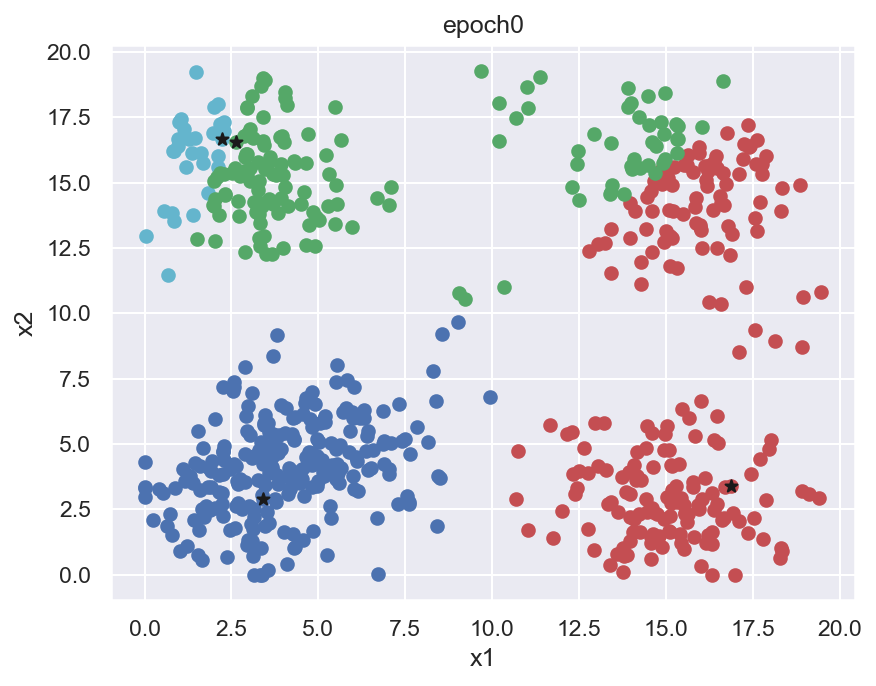

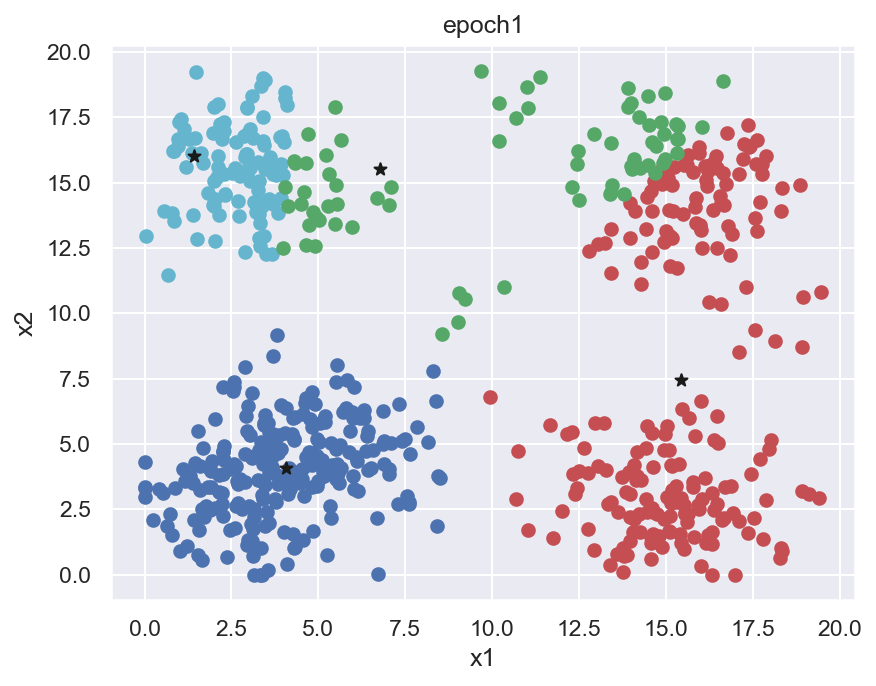

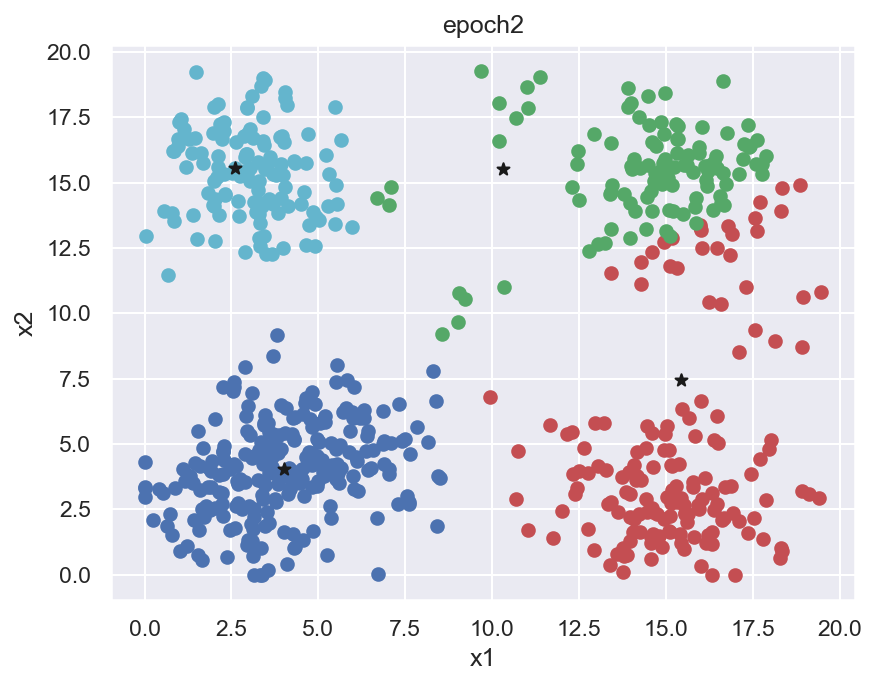

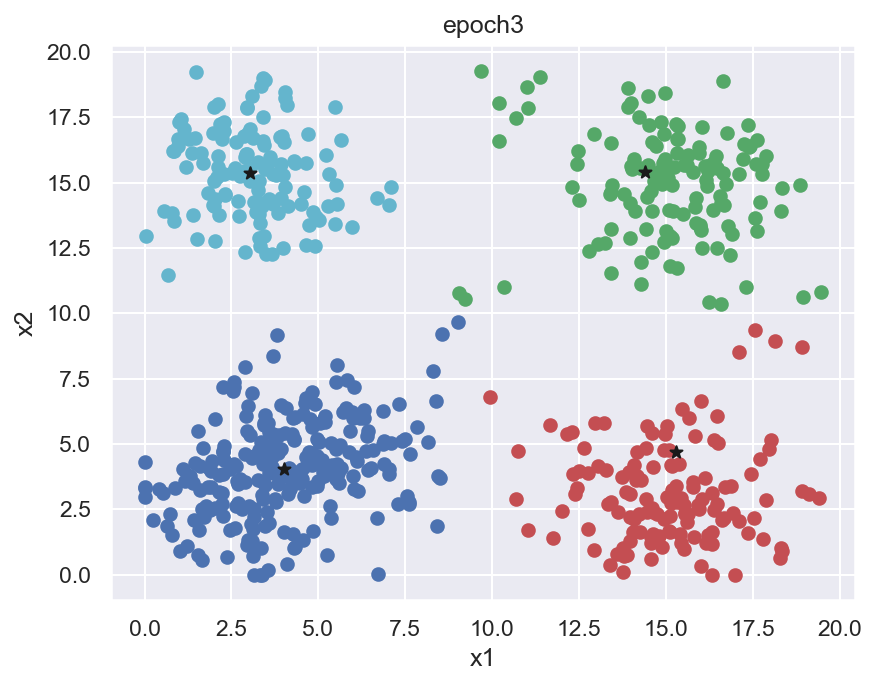

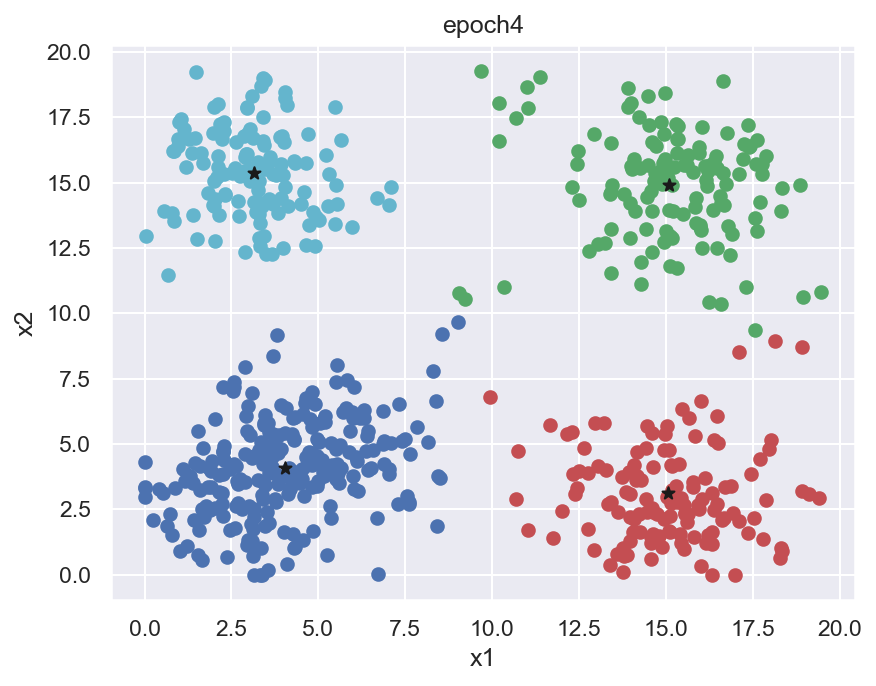

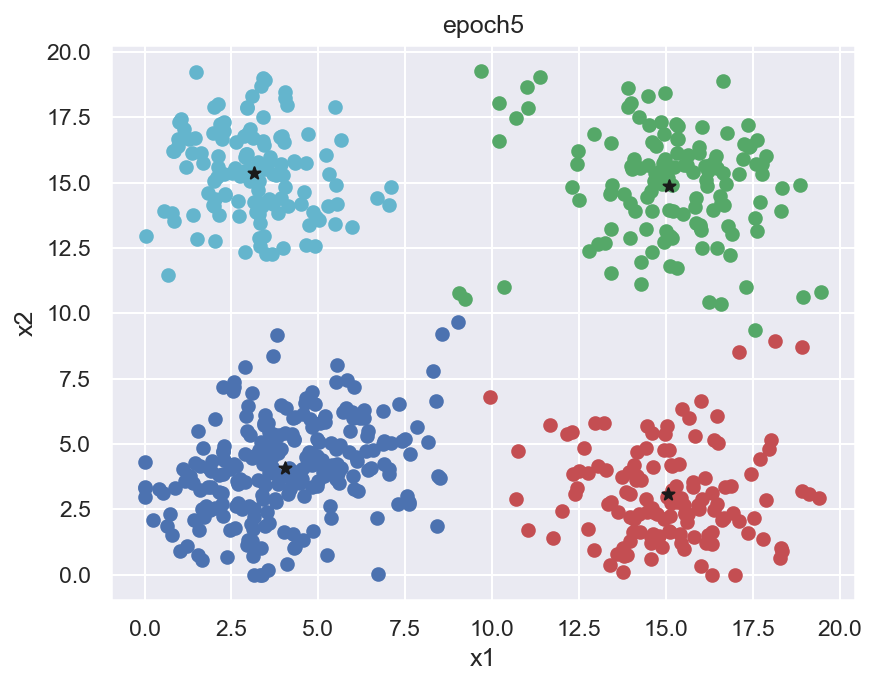

In [134]:
assignment, _ = kmeans(X, k, max_epoch)

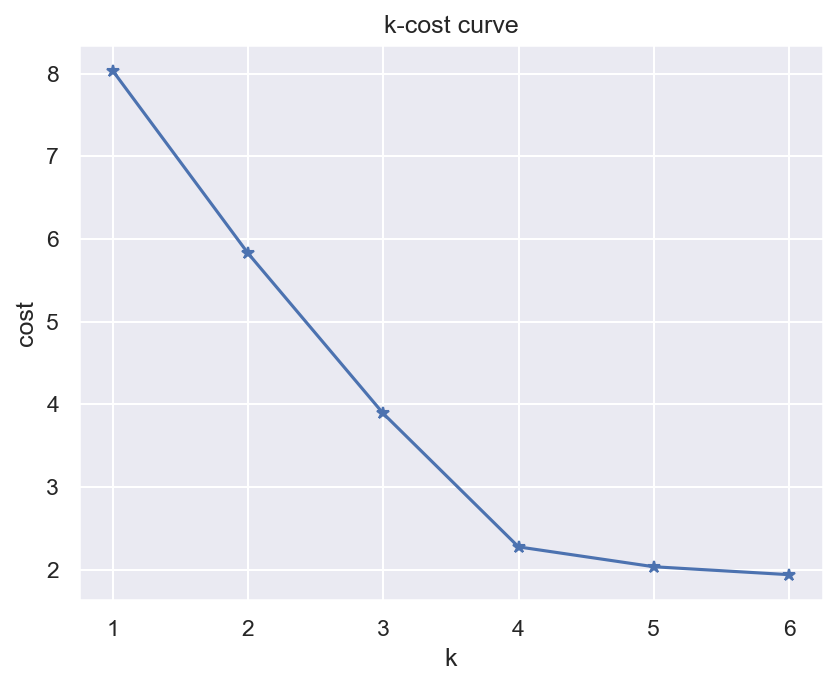

In [135]:
#绘制簇数-代价函数曲线：根据曲线，观察最合适的簇数k的选择
plt.figure(dpi=150)
Cost = []
max_k = 7
for k in range(1, max_k):
    _, cost = kmeans(X, k, max_epoch,False)
    Cost.append(cost)

plt.plot(range(1,max_k), Cost, c='b', marker = '*')
plt.xticks(range(1,max_k))
plt.xlabel('k')
plt.ylabel('cost')
plt.title('k-cost curve')
plt.show()